In [4]:
import pandas as pd
import numpy as np
df = pd.DataFrame({

    'Tower_Id': [101,102,103,104,105,106,107,108,109,110],
    'City': ['Delhi','Delhi','Noida','Delhi','Noida','Gurgaon','Delhi','Noida','Gurgaon','Delhi'],
    'Engineer': ['Ravi','Mohan','Ravi','Ankit','Mohan','Ankit','ravi','Mohan','Ankit','Ravi'],
    'Signal_Strength': [75,np.nan,65,45,82,90,30,55,np.nan,72],
    'Downtime_Hours': [3,8,2,15,1,0,22,6,12,2],
    'Customer_Complaints': [5,20,3,45,1,0,60,12,30,4],
    'Maintenance_Cost': [5000,12000,4500,25000,3000,2000,30000,9000,15000,4000],
    'Last_service_Date': ['2025-01-10','2025-01-15','2025-02-01','2024-12-20','2025-03-01','2025-03-15','2024-11-01','2025-02-20','2024-10-10 ','2025-03-05']
                          })
print(df)

   Tower_Id     City Engineer  Signal_Strength  Downtime_Hours  \
0       101    Delhi     Ravi             75.0               3   
1       102    Delhi    Mohan              NaN               8   
2       103    Noida     Ravi             65.0               2   
3       104    Delhi    Ankit             45.0              15   
4       105    Noida    Mohan             82.0               1   
5       106  Gurgaon    Ankit             90.0               0   
6       107    Delhi     ravi             30.0              22   
7       108    Noida    Mohan             55.0               6   
8       109  Gurgaon    Ankit              NaN              12   
9       110    Delhi     Ravi             72.0               2   

   Customer_Complaints  Maintenance_Cost Last_service_Date  
0                    5              5000        2025-01-10  
1                   20             12000        2025-01-15  
2                    3              4500        2025-02-01  
3                   45       

In [ ]:
# Data Cleaning

In [ ]:
# Checking Missing Values

In [10]:
df.isnull().sum()

Tower_Id               0
City                   0
Engineer               0
Signal_Strength        2
Downtime_Hours         0
Customer_Complaints    0
Maintenance_Cost       0
Last_service_Date      0
dtype: int64

In [ ]:
# Replace missing signal strength with city average

In [15]:
df_Replace_Signal_Strength = df.groupby("City")["Signal_Strength"].apply(lambda x:x.fillna(x.mean()))
print(df_Replace_Signal_Strength)

City      
Delhi    0    75.0
         1    55.5
         3    45.0
         6    30.0
         9    72.0
Gurgaon  5    90.0
         8    90.0
Noida    2    65.0
         4    82.0
         7    55.0
Name: Signal_Strength, dtype: float64


In [ ]:
# Convert Last Service Date into Datetime

In [27]:
df_Service_Date = pd.to_datetime(df['Last_service_Date'].str.strip())
print(df_Service_Date)

0   2025-01-10
1   2025-01-15
2   2025-02-01
3   2024-12-20
4   2025-03-01
5   2025-03-15
6   2024-11-01
7   2025-02-20
8   2024-10-10
9   2025-03-05
Name: Last_service_Date, dtype: datetime64[ns]


In [ ]:
# Standardize city names to uppercase

In [34]:
df_City_Name = df['City'].str.upper()
print(df_City_Name)

0      DELHI
1      DELHI
2      NOIDA
3      DELHI
4      NOIDA
5    GURGAON
6      DELHI
7      NOIDA
8    GURGAON
9      DELHI
Name: City, dtype: object


In [ ]:
# Remove duplicate rows

In [37]:
df_Remove_Duplicate_Rows = df.drop_duplicates()
print(df_Remove_Duplicate_Rows)

   Tower_Id     City Engineer  Signal_Strength  Downtime_Hours  \
0       101    Delhi     Ravi             75.0               3   
1       102    Delhi    Mohan              NaN               8   
2       103    Noida     Ravi             65.0               2   
3       104    Delhi    Ankit             45.0              15   
4       105    Noida    Mohan             82.0               1   
5       106  Gurgaon    Ankit             90.0               0   
6       107    Delhi     ravi             30.0              22   
7       108    Noida    Mohan             55.0               6   
8       109  Gurgaon    Ankit              NaN              12   
9       110    Delhi     Ravi             72.0               2   

   Customer_Complaints  Maintenance_Cost Last_service_Date  
0                    5              5000        2025-01-10  
1                   20             12000        2025-01-15  
2                    3              4500        2025-02-01  
3                   45       

In [ ]:
# find towers having Signal < 50 & Complaints > 20

In [40]:
df = df.loc[(df['Signal_Strength']<50) & (df['Customer_Complaints']>20)]
print(df)

   Tower_Id   City Engineer  Signal_Strength  Downtime_Hours  \
3       104  Delhi    Ankit             45.0              15   
6       107  Delhi     ravi             30.0              22   

   Customer_Complaints  Maintenance_Cost Last_service_Date  
3                   45             25000        2024-12-20  
6                   60             30000        2024-11-01  


In [ ]:
# Find towers with Downtime > 10 OR Maintenance Cost >20000

In [43]:
df_towers = df.loc[(df['Downtime_Hours']>10) | (df['Maintenance_Cost']>20000)]
print(df_towers)

   Tower_Id   City Engineer  Signal_Strength  Downtime_Hours  \
3       104  Delhi    Ankit             45.0              15   
6       107  Delhi     ravi             30.0              22   

   Customer_Complaints  Maintenance_Cost Last_service_Date  
3                   45             25000        2024-12-20  
6                   60             30000        2024-11-01  


In [44]:
df_Tower = df[(df['Downtime_Hours']>10) | (df['Maintenance_Cost']>20000)]
print(df_Tower)

   Tower_Id   City Engineer  Signal_Strength  Downtime_Hours  \
3       104  Delhi    Ankit             45.0              15   
6       107  Delhi     ravi             30.0              22   

   Customer_Complaints  Maintenance_Cost Last_service_Date  
3                   45             25000        2024-12-20  
6                   60             30000        2024-11-01  


In [ ]:
# Increase Maintenance Cost by 10% where Downtime > 15

In [51]:
df_Maintenance_Cost = df.loc[df['Downtime_Hours']>15,'Maintenance_Cost'] * 1.1
print(df_Maintenance_Cost)

6    33000.0
Name: Maintenance_Cost, dtype: float64


In [ ]:
# Replace Signal Strength below 40 with 40

In [6]:
df_signal_strength = df.loc[df['Signal_Strength']<40,'Signal_Strength'] = 40
print(df_signal_strength)

40


In [ ]:
# Create Performance Score

In [15]:
df['Performance_Score'] = df.apply(lambda x: x['Signal_Strength']-x['Downtime_Hours']-(x['Customer_Complaints']/2),axis=1)
print(df['Performance_Score'])

0    69.5
1     NaN
2    61.5
3     7.5
4    80.5
5    90.0
6   -12.0
7    43.0
8     NaN
9    68.0
Name: Performance_Score, dtype: float64


In [58]:
type(df)

pandas.core.frame.DataFrame

In [ ]:
# Create Tower Status

In [67]:
df_Tower_Status = df['Performance_Score'].apply(lambda x: 'Excellent' 
                                                 if x>60 
                                                 else 'Average' 
                                                 if x>=40 
                                                 else 'Poor' 
                                                )
print(df_Tower_Status)

0    Excellent
1         Poor
2    Excellent
3         Poor
4    Excellent
5    Excellent
6         Poor
7      Average
8         Poor
9    Excellent
Name: Performance_Score, dtype: object


In [69]:
df.loc[:, 'Performance_Score']

0    69.5
1     NaN
2    61.5
3     7.5
4    80.5
5    90.0
6   -12.0
7    43.0
8     NaN
9    68.0
Name: Performance_Score, dtype: float64

In [ ]:
# Average Signal by city

In [4]:
df_Average_Signal = df.groupby('City')['Signal_Strength'].mean()
print(df_Average_Signal)

City
Delhi      55.500000
Gurgaon    90.000000
Noida      67.333333
Name: Signal_Strength, dtype: float64


In [ ]:
# Total Complaints by Engineer

In [6]:
df_Complaints = df.groupby('Engineer')['Customer_Complaints'].sum()
print(df_Complaints)

Engineer
Ankit    75
Mohan    33
Ravi     12
ravi     60
Name: Customer_Complaints, dtype: int64


In [ ]:
# Maximum Downtime by City

In [7]:
df_Downtime = df.groupby('City')['Downtime_Hours'].max()
print(df_Downtime)

City
Delhi      22
Gurgaon    12
Noida       6
Name: Downtime_Hours, dtype: int64


In [ ]:
# Top 5 Towers with Highest Complaints

In [13]:
df_Highest_complaints = df[['Tower_Id','Customer_Complaints']].sort_values(by = 'Customer_Complaints' , ascending = False).head(5)
print(df_Highest_complaints)

   Tower_Id  Customer_Complaints
6       107                   60
3       104                   45
8       109                   30
1       102                   20
7       108                   12


In [ ]:
# top 3 cities By Dowmtime

In [16]:
df_Top_cities = df[['City','Downtime_Hours']].groupby('City')['Downtime_Hours'].sum().sort_values(ascending=False).head(3)
print(df_Top_cities)

City
Delhi      50
Gurgaon    12
Noida       9
Name: Downtime_Hours, dtype: int64


In [ ]:
# Create defrisk_level()

In [19]:
def Risk_Level(Downtime_Hours):
      if Downtime_Hours>15: 
          return 'High_Risk' 
      elif Downtime_Hours>=5: 
          return 'Medium_Risk' 
      else: 
          return 'Low_Risk'
df['Risk_Level']= df['Downtime_Hours'].apply(Risk_Level)
print(df[['Downtime_Hours', 'Risk_Level']].head())
                               

   Downtime_Hours   Risk_Level
0               3     Low_Risk
1               8  Medium_Risk
2               2     Low_Risk
3              15  Medium_Risk
4               1     Low_Risk


In [ ]:
# Create days Since Last service

In [24]:
df['Last_service_Date'] = pd.to_datetime(df['Last_service_Date'].str.strip())
today=pd.Timestamp.today()
df['Days_Since_Last_Service']=(today-df['Last_service_Date']).dt.days
print(df['Days_Since_Last_Service'])

0    524
1    519
2    502
3    545
4    474
5    460
6    594
7    483
8    616
9    470
Name: Days_Since_Last_Service, dtype: int64


In [ ]:
# Create Maintenance Efficiency

In [12]:
df['Maintenance_Efficiency'] = (df['Signal_Strength'] / df['Maintenance_Cost'])
print(df['Maintenance_Efficiency'])

0    0.015000
1         NaN
2    0.014444
3    0.001800
4    0.027333
5    0.045000
6    0.001000
7    0.006111
8         NaN
9    0.018000
Name: Maintenance_Efficiency, dtype: float64


In [ ]:
# Create Another dataframe

In [10]:
city_df = pd.DataFrame({

    'City': ['Delhi','Noida','Gurgaon'],
    'Population': [20000000,800000,1500000]
})
print(city_df)

      City  Population
0    Delhi    20000000
1    Noida      800000
2  Gurgaon     1500000


In [ ]:
# merge both the tables

In [13]:
df_Merge_Table = df.merge(city_df,
                         on='City',
                         how='left'
                         )
print(df_Merge_Table)

   Tower_Id     City Engineer  Signal_Strength  Downtime_Hours  \
0       101    Delhi     Ravi             75.0               3   
1       102    Delhi    Mohan              NaN               8   
2       103    Noida     Ravi             65.0               2   
3       104    Delhi    Ankit             45.0              15   
4       105    Noida    Mohan             82.0               1   
5       106  Gurgaon    Ankit             90.0               0   
6       107    Delhi     ravi             30.0              22   
7       108    Noida    Mohan             55.0               6   
8       109  Gurgaon    Ankit              NaN              12   
9       110    Delhi     Ravi             72.0               2   

   Customer_Complaints  Maintenance_Cost Last_service_Date  \
0                    5              5000        2025-01-10   
1                   20             12000        2025-01-15   
2                    3              4500        2025-02-01   
3                   45   

In [ ]:
# Create Rows = City Columns = Engineer Values = Customer complaints using PIVOT Table

In [15]:
Pivot_table = pd.pivot_table(df,
                             values = 'Customer_Complaints',
                             index = 'City',
                             columns = 'Engineer',
                             aggfunc = 'sum'
)
print(Pivot_table )

Engineer  Ankit  Mohan  Ravi  ravi
City                              
Delhi      45.0   20.0   9.0  60.0
Gurgaon    30.0    NaN   NaN   NaN
Noida       NaN   13.0   3.0   NaN


In [ ]:
# Prepare Bar Chart City Vs Complaints

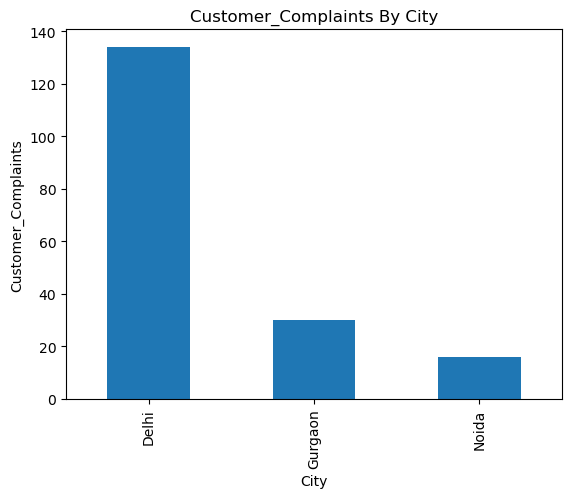

In [22]:
import matplotlib.pyplot as plt
df_Complaints = df.groupby('City')['Customer_Complaints'].sum()
df_Complaints.plot(kind='bar')
plt.xlabel('City')
plt.ylabel('Customer_Complaints')
plt.title('Customer_Complaints By City')

plt.show()

In [ ]:
# Prepare scatter plot for Signal Vs Complaints

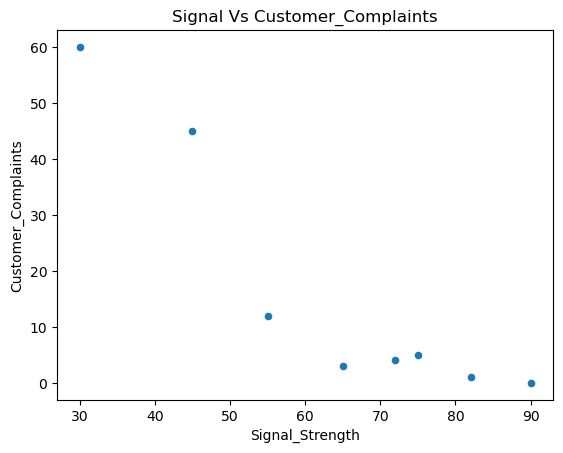

In [26]:
df.plot(kind='scatter',
x = 'Signal_Strength',
y = 'Customer_Complaints')
plt.xlabel('Signal_Strength')
plt.ylabel('Customer_Complaints')
plt.title('Signal Vs Customer_Complaints')

plt.show()

In [ ]:
# prepare Historam for Downtime Distribution

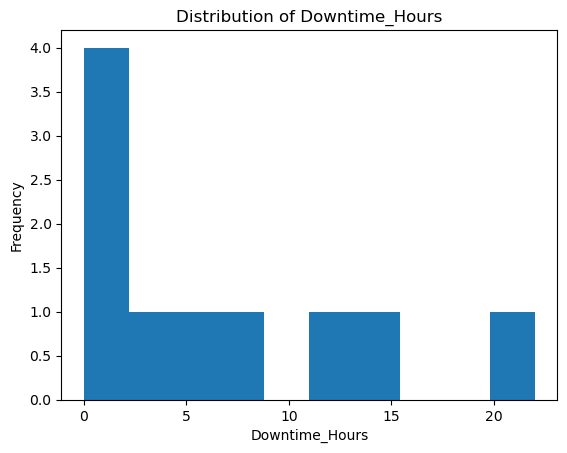

In [27]:
df['Downtime_Hours'].plot(
    kind='hist',
    bins=10
)

plt.xlabel('Downtime_Hours')
plt.ylabel('Frequency')
plt.title('Distribution of Downtime_Hours')

plt.show()

In [ ]:
# Towers which have signal below city average

In [7]:
df_Towers = df[
    df['Signal_Strength'] <
    df.groupby('City')['Signal_Strength'].transform('mean')
]
print(df_Towers)


   Tower_Id   City Engineer  Signal_Strength  Downtime_Hours  \
2       103  Noida     Ravi             65.0               2   
3       104  Delhi    Ankit             45.0              15   
6       107  Delhi     ravi             30.0              22   
7       108  Noida    Mohan             55.0               6   

   Customer_Complaints  Maintenance_Cost Last_service_Date  
2                    3              4500        2025-02-01  
3                   45             25000        2024-12-20  
6                   60             30000        2024-11-01  
7                   12              9000        2025-02-20  


In [ ]:
# rank towers by their performance score

In [10]:
df['Rank'] = df['Performance_Score'].rank(
    ascending=False,
    method='dense'
)
print(df['Rank'])

0    3.0
1    NaN
2    5.0
3    7.0
4    2.0
5    1.0
6    8.0
7    6.0
8    NaN
9    4.0
Name: Rank, dtype: float64


In [ ]:
# Bottom 5 Towers

In [19]:
df_Bottom_Towers = df['Performance_Score'].sort_values(ascending = True).head(3)
print(df_Bottom_Towers)

6   -22.0
3     7.5
7    43.0
Name: Performance_Score, dtype: float64


In [ ]:
# Engineers who have minimum downtime hours

In [14]:
df_Min_Downtime_Hours = df.loc[df['Downtime_Hours'].idxmin()],['Engineer','Downtime_Hours']
print(df_Min_Downtime_Hours)

(Tower_Id                      106
City                      Gurgaon
Engineer                    Ankit
Signal_Strength              90.0
Downtime_Hours                  0
Customer_Complaints             0
Maintenance_Cost             2000
Last_service_Date      2025-03-15
Name: 5, dtype: object, ['Engineer', 'Downtime_Hours'])


In [ ]:
# City with highest complaint per tower ratio

In [17]:
df_City_Highest_Complaint = df.loc[df['Customer_Complaints'].idxmax()],['City', 'Customer_Complaints']


In [22]:
city_ratio = df.groupby('City').agg({
    'Customer_Complaints': 'sum',
    'Tower_Id': 'count'
})
city_ratio['Complaint_Per_Tower'] = (
    city_ratio['Customer_Complaints'] /
    city_ratio['Tower_Id']
)

print(city_ratio)

         Customer_Complaints  Tower_Id  Complaint_Per_Tower
City                                                       
Delhi                    134         5            26.800000
Gurgaon                   30         2            15.000000
Noida                     16         3             5.333333


In [ ]:
# Towers for Replacement

In [29]:
def Tower_Need_Replacement(row): 
                            if (row['Signal_Strength']<40 &
                                row['Customer_Complaints']>25 &
                                row['Downtime_Hours']>10):
                                return 'Yes'
                            else: 'No'
df['Tower_Need_Replacement'] = df.apply(Tower_Need_Replacement,axis=1)
print(df['Tower_Need_Replacement'])

0    None
1    None
2    None
3    None
4    None
5    None
6     Yes
7    None
8    None
9    None
Name: Tower_Need_Replacement, dtype: object


In [37]:
df['Engineer'].str.title()

0     Ravi
1    Mohan
2     Ravi
3    Ankit
4    Mohan
5    Ankit
6     Ravi
7    Mohan
8    Ankit
9     Ravi
Name: Engineer, dtype: object

In [ ]:
# Best Engineer & Worst Engineer

In [31]:
df['Engineer'] = df['Engineer'].str.title()
print(df['Engineer'])

0     Ravi
1    Mohan
2     Ravi
3    Ankit
4    Mohan
5    Ankit
6     Ravi
7    Mohan
8    Ankit
9     Ravi
Name: Engineer, dtype: object


In [43]:
engineer_performance = df.groupby('Engineer')['Performance_Score'].mean()

best_engineer = engineer_performance.idxmax()
worst_engineer = engineer_performance.idxmin()

print("Best Engineer:", best_engineer)
print("Worst Engineer:", worst_engineer)

Best Engineer: Mohan
Worst Engineer: Ravi


In [42]:
engineer_performance = df.groupby('Engineer')['Performance_Score'].mean()

print(engineer_performance)
print()
print("Max Score:", engineer_performance.max())
print("Min Score:", engineer_performance.min())

Engineer
Ankit    48.75
Mohan    61.75
Ravi     46.75
Name: Performance_Score, dtype: float64

Max Score: 61.75
Min Score: 46.75


In [ ]:
# Best City & Worst City

In [33]:
city_performance = df.groupby('City')['Performance_Score'].mean()

best_city = city_performance.idxmax()
worst_city = city_performance.idxmin()
kpi = pd.DataFrame({
    'Metric':['Best City','Worst City'],
    'Value':[best_city,worst_city]
})
from IPython.display import display

display(kpi)

,Metric,Value
0,Best City,Gurgaon
1,Worst City,Delhi


In [ ]:
# Top 5 Towers

In [34]:
top5_towers = df.sort_values(
                    by='Performance_Score',
                    ascending=False
                ).head(5)
print(top5_towers)

   Tower_Id     City Engineer  Signal_Strength  Downtime_Hours  \
5       106  Gurgaon    Ankit             90.0               0   
4       105    Noida    Mohan             82.0               1   
0       101    Delhi     Ravi             75.0               3   
9       110    Delhi     Ravi             72.0               2   
2       103    Noida     Ravi             65.0               2   

   Customer_Complaints  Maintenance_Cost Last_service_Date  Performance_Score  
5                    0              2000        2025-03-15               90.0  
4                    1              3000        2025-03-01               80.5  
0                    5              5000        2025-01-10               69.5  
9                    4              4000        2025-03-05               68.0  
2                    3              4500        2025-02-01               61.5  


In [ ]:
# Bottom 5 towers

In [35]:
bottom5_towers = df.sort_values(
                    by='Performance_Score',
                    ascending=True
                ).head(5)

print(bottom5_towers)

   Tower_Id   City Engineer  Signal_Strength  Downtime_Hours  \
6       107  Delhi     Ravi             40.0              22   
3       104  Delhi    Ankit             45.0              15   
7       108  Noida    Mohan             55.0               6   
2       103  Noida     Ravi             65.0               2   
9       110  Delhi     Ravi             72.0               2   

   Customer_Complaints  Maintenance_Cost Last_service_Date  Performance_Score  
6                   60             30000        2024-11-01              -12.0  
3                   45             25000        2024-12-20                7.5  
7                   12              9000        2025-02-20               43.0  
2                    3              4500        2025-02-01               61.5  
9                    4              4000        2025-03-05               68.0  


In [ ]:
# high risk towers

In [36]:
def risk_level(row):

    if row['Downtime_Hours'] > 15:
        return 'High Risk'

    elif row['Downtime_Hours'] >= 5:
        return 'Medium Risk'

    else:
        return 'Low Risk'
df['Risk_Level'] = df.apply(
                        risk_level,
                        axis=1
                    )
high_risk = df.loc[
                df['Risk_Level']=='High Risk'
            ]

print(high_risk)

   Tower_Id   City Engineer  Signal_Strength  Downtime_Hours  \
6       107  Delhi     Ravi             40.0              22   

   Customer_Complaints  Maintenance_Cost Last_service_Date  Performance_Score  \
6                   60             30000        2024-11-01              -12.0   

  Risk_Level  
6  High Risk  


In [ ]:
# estimated Maintenance Budget

In [37]:
current_budget = df['Maintenance_Cost'].sum()

print(current_budget)
recommended_budget = current_budget * 1.10

print(recommended_budget)

109500
120450.00000000001


In [ ]:
# Towers Due For Service

In [ ]:
# Upgrade recommendation

In [10]:
upgrade = df.loc[
                (df['Signal_Strength'] < 40)
                &
                (df['Customer_Complaints'] > 25)
                &
                (df['Downtime_Hours'] > 10)
            ]

print(upgrade)

Empty DataFrame
Columns: [Tower_Id, City, Engineer, Signal_Strength, Downtime_Hours, Customer_Complaints, Maintenance_Cost, Last_service_Date]
Index: []


In [44]:
management_report = pd.DataFrame({

'KPI':[
'Best City',
'Worst City',
'Best Engineer',
'Worst Engineer',
'Maintenance Budget'
],

'Result':[
best_city,
worst_city,
best_engineer,
worst_engineer,
current_budget

]

})

display(management_report)

,KPI,Result
0,Best City,Gurgaon
1,Worst City,Delhi
2,Best Engineer,Mohan
3,Worst Engineer,Ravi
4,Maintenance Budget,109500


In [45]:
management_report = pd.DataFrame({
'KPI':[
        '🏆 Best City',
        '⚠️ Worst City',
        '🥇 Best Engineer',
        '🔻 Worst Engineer',
        '💰 Current Budget',
        '📈 Recommended Budget'
    ],

    'Result':[
        best_city,
        worst_city,
        best_engineer,
        worst_engineer,
        f"₹{current_budget:,.0f}",
        f"₹{recommended_budget:,.0f}"
    ]

})

display(management_report)

,KPI,Result
0,🏆 Best City,Gurgaon
1,⚠️ Worst City,Delhi
2,🥇 Best Engineer,Mohan
3,🔻 Worst Engineer,Ravi
4,💰 Current Budget,"₹109,500"
5,📈 Recommended Budget,"₹120,450"
